In [36]:
import matplotlib.pyplot as plt
import numpy as np
#from sklearn.datasets import load_files
from pyvi import ViTokenizer # Tách từ tiếng Việt
import sklearn.naive_bayes as naive_bayes
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve

%matplotlib inline

In [37]:
data_train = load_files(container_path="data/news_1135/", encoding="utf-8")
print(data_train.filenames)
print()
print("Tong so file: {}" .format( len(data_train.filenames)))
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )


['data/news_1135/Thể thao\\2e62de81ade8318f66cc740f5ede5607ea1bf002.txt'
 'data/news_1135/Thể thao\\f9bd156031140a7db52ae51de4561f234a0eb277.txt'
 'data/news_1135/Thể thao\\aeeb3b3b0dfc936de928f0b004259aca70aa4efa.txt'
 'data/news_1135/Thể thao\\7787f359bd1efeee382a8077a7725e03b01e3a53.txt'
 'data/news_1135/Thể thao\\cf967f8831bf7102304dce974b370ad26991fc65.txt'
 'data/news_1135/Thể thao\\92169a7c47b1661f24aa1651f418490049c95cac.txt'
 'data/news_1135/Sức khỏe\\b6c8c39ad177edc5b6b7509f7c21eebe21631970.txt'
 'data/news_1135/Thể thao\\f206d5fcf67b820dbe314e7d152f5b2d181e38c1.txt'
 'data/news_1135/Sức khỏe\\f6b9942c0ab5548ede99940d6ed1dd6fd3b36dbe.txt'
 'data/news_1135/Sức khỏe\\24181828a2a95af5c40505922a64bb6fb177e266.txt'
 'data/news_1135/Thể thao\\4075a388765339747f4e5961a0a34a9bcf953413.txt'
 'data/news_1135/Sức khỏe\\774c529f2193777355fa684446dd195f79391d9c.txt'
 'data/news_1135/Sức khỏe\\0fb06f1f48bba02087ae57d6625573d9e1d2e77a.txt'
 'data/news_1135/Thể thao\\86def9a683b6d9c5f3aea66f

In [38]:
print('- Noi dung cua van ban dau tien:', data_train.data[0])
print()
print('- Nhan cua van ban dau tien:', end=' ')
print(data_train.target_names[0])


- Noi dung cua van ban dau tien: Dân_trí Sáng 5/12 , giải quần_vợt các tay_vợt xuất_sắc Việt_Nam - Cúp Vietravel 2016 đã chính_thức khai_mạc tại TP Vinh - Nghệ_An . Tham_dự giải hơn 30 tay_vợt xuất_sắc nhất của Liên_đoàn quần_vợt Việt_Nam . Dự lễ khai_mạc có ông Nguyễn Trọng Hổ - Vụ_trưởng Vụ thể_thao thành_tích cao II ; Đoàn Quốc Cường - Trưởng bộ_môn quần_vợt Liên_đoàn quần_vợt Việt_Nam ; Nguyễn Quốc Kỳ - Tổng_Giám_đốc Viettravel , Phó_Chủ_tịch kiêm Tổng_thư_ký Liên_đoàn quần_vợt Việt_Nam cùng lãnh_đạo tỉnh Nghệ_An . Giải quần_vợt các cây_vợt xuất_sắc Việt_Nam - Cup Vietravel 2016 do Liên_đoàn Quần_vợt Việt_Nam VTF phối_hợp với Sở VH - TT - DL và Liên_đoàn quần_vợt Nghệ_An NTF tổ_chức ; là giải đấu chuyên_nghiệp quốc_gia lần đầu_tiên được tổ_chức tại Nghệ_An . Ông Nguyễn Quốc Kỳ - PCT kiêm TTK Liên_đoàn quần_vợt Việt_Nam Tham_gia giải lần này có 22 VĐV nam , 9 VĐV nữ có điểm xếp_hạng cao nhất của bộ_môn quần_vợt chuyên_nghiệp , đến từ các trung_tâm quần_vợt lớn trong cả nước như : Th

In [39]:
# load dữ liệu các stopwords
with open("data/vietnamese-stopwords.txt",encoding="utf8") as f:
    stopwords = f.readlines()
stopwords = [x.strip().replace(" ", "_") for x in stopwords]
print("Danh sách 10 từ dừng đầu tiên (từ không mang ý nghĩa phân loại): ", stopwords[:10])
print()
#
# Transforming data
# Chuyển hoá dữ liệu text về dạng vector tfidf
# - loại bỏ từ dừng
# - sinh từ điển
module_count_vector = CountVectorizer(stop_words=stopwords)
model_rf_preprocess = Pipeline([('vect', module_count_vector),('tfidf', TfidfTransformer()),])

# Hàm thực hiện chuyển đổi dữ liệu text thành dữ liệu số dạng ma trận
# Input: Dữ liệu 2 chiều dạng numpy.array, mảng nhãn id dạng numpy.array

# Tiền xử lý với Bag of words
data_bow = module_count_vector.fit_transform(data_train.data, data_train.target)
# Tiền xử lý với TF-IDF
data_tfidf = model_rf_preprocess.fit_transform(data_train.data, data_train.target)

print("10 từ đầu tiên trong từ điển:\n")

# sort the order of the dictionary by the frequency of the word in the vector
module_count_vector.vocabulary_ = dict(sorted(module_count_vector.vocabulary_.items(), key=lambda item: item[1]))
# reverse the order of the dictionary
module_count_vector.vocabulary_ = dict(reversed(list(module_count_vector.vocabulary_.items())))

i = 0
for k,v in module_count_vector.vocabulary_.items():
    i += 1
    print(i, ": ", (k, v))
    if i > 10:
        break
print()


Danh sách 10 từ dừng đầu tiên (từ không mang ý nghĩa phân loại):  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']

10 từ đầu tiên trong từ điển:

1 :  ('ứng_xử', 7971)
2 :  ('ứng_viên', 7970)
3 :  ('ứng_phó', 7969)
4 :  ('ứng_dụng', 7968)
5 :  ('ứng_cử', 7967)
6 :  ('ứng', 7966)
7 :  ('ức_chế', 7965)
8 :  ('ủy', 7964)
9 :  ('ủng_hộ', 7963)
10 :  ('ủng', 7962)
11 :  ('ở_mùa', 7961)



In [40]:
from sklearn.model_selection import train_test_split

test_size = 0.2

X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(data_bow, data_train.target, test_size=test_size, random_state=30)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(data_tfidf, data_train.target, test_size=test_size, random_state=30)

X_train_bow.shape, X_test_bow.shape, y_train_bow.shape, y_test_bow.shape

((179, 7972), (45, 7972), (179,), (45,))

In [41]:
print(y_train_bow[:10])
print(X_train_bow[:10].shape)

[5 5 4 6 5 4 4 6 4 5]
(10, 7972)


In [42]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import GaussianNB

#import accuracy_score
from sklearn.metrics import accuracy_score

model_nb_bow = MultinomialNB(alpha = 0.1)
model_nb_bow.fit(X_train_bow, y_train_bow)
print("Độ chính xác trên tập test với BoW: ", model_nb_bow.score(X_test_bow, y_test_bow))

model_nb_tfidf = GaussianNB()
model_nb_tfidf.fit(X_train_tfidf.toarray(), y_train_tfidf)
print("Độ chính xác trên tập test với TF-IDF: ", model_nb_tfidf.score(X_test_tfidf.toarray(), y_test_tfidf))




Độ chính xác trên tập test với BoW:  0.9555555555555556


Độ chính xác trên tập test với TF-IDF:  0.9333333333333333


In [43]:
a = ViTokenizer.tokenize("Trường đại học bách khoa hà nội")
print(a)

Trường đại_học bách_khoa hà_nội


In [44]:
# tiền xử lý dữ liệu sử dụng module module_count_vector.

van_ban = ["Hoàng Gia rất béo và giảm cân", "Tâm trần rất"]
van_ban = [ViTokenizer.tokenize(i) for i in van_ban]
#van_ban_moi = ["Công_phượng ghi_bàn cho đội_tuyển Việt_nam"]

input_data_preprocessed = module_count_vector.transform(van_ban)
print(input_data_preprocessed)
print()
print("Danh sách nhãn và id tương ứng: ", [(idx, name) for idx, name in enumerate(data_train.target_names)] )


<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 4 stored elements and shape (2, 7972)>
  Coords	Values
  (0, 705)	1
  (0, 1503)	1
  (1, 6380)	1
  (1, 6527)	1

Danh sách nhãn và id tương ứng:  [(0, 'Giải trí'), (1, 'Khoa học - Công nghệ'), (2, 'Kinh tế'), (3, 'Pháp luật'), (4, 'Sức khỏe'), (5, 'Thể thao'), (6, 'Thời sự')]


In [45]:
y_pred_bow = model_nb_bow.predict(input_data_preprocessed)
for i in range(len(van_ban)):
    print("Văn bản: ", van_ban[i])
    print("Dự đoán nhãn của văn bản mới với BoW: ", data_train.target_names[y_pred_bow[i]])
    print()

Văn bản:  Hoàng_Gia rất béo và giảm cân
Dự đoán nhãn của văn bản mới với BoW:  Sức khỏe

Văn bản:  Tâm trần rất
Dự đoán nhãn của văn bản mới với BoW:  Sức khỏe



0.1 0.9555555555555556
0.01 0.9555555555555556
0.001 0.9555555555555556
0.0001 0.9555555555555556
1e-05 0.9555555555555556


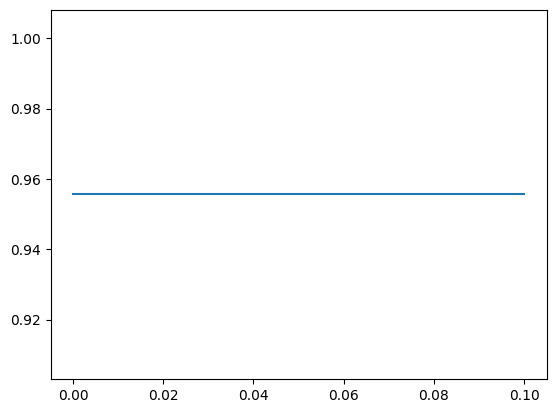

In [46]:
var_smoothings = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
accs = []
for var_smoothing in var_smoothings:
    model_GNB = naive_bayes.GaussianNB(var_smoothing=1e-3)
    model_GNB.fit(X_train_tfidf.toarray(), y_train_tfidf)
    #Hoàn thiện thêm phần code ở đây để ghi nhận acc tương ứng trong từng trường hợp

    y_pred_tfidf = model_GNB.predict(X_test_tfidf.toarray())
    acc = accuracy_score(y_test_tfidf, y_pred_tfidf)
    accs.append(acc)

#Minh họa tương quan bằng đồ thị::
#Gợi ý: barplot, lineplot, ...
import seaborn as sns
sns.lineplot(x=var_smoothings, y = accs)
############
for i in range(len(accs)):
    print(var_smoothings[i], accs[i])